# CSE422 — Artificial Intelligence Lab Project
# Predicting Diabetes from Routine Health Metrics

**Group 07** &nbsp;|&nbsp; **Course:** CSE422 (Artificial Intelligence) &nbsp;|&nbsp; **Dataset:** `7.csv`

**Members:** Tahamidul Alam Chowdhury (ID: 22299066), Mehedi Zaman Sami (ID: 22299481)

---
This notebook follows the lab guideline section by section: **Introduction → Dataset Description → Data Analysis (EDA) → Pre-processing → Model Training → Model Evaluation → Conclusion**. Every number and plot below is computed live from the dataset — nothing is hard-coded — so re-running this notebook top to bottom will reproduce the same results.

## 1. Introduction

### 1.1 Problem and motivation

Diabetes is one of the most common chronic conditions worldwide, and a large share of cases go undiagnosed simply because full diagnostic testing (fasting glucose, HbA1c) isn't always accessible. Routine measurements — age, BMI, blood pressure, heart rate, cholesterol, body temperature, smoking status — are far cheaper and already collected in most check-ups. If those routine numbers carry any signal about diabetes risk, they could support low-cost early screening.

**Aim of this project:** use the health-metrics dataset (`7.csv`) to build and compare several machine learning models — a Neural Network plus several classical classifiers — that predict whether a person has diabetes from these routine metrics. We then set the labels aside entirely and apply **K-Means clustering**, to see whether the data naturally separates into groups that happen to line up with diabetic / non-diabetic status.

### 1.2 Target feature

The guideline asks for one feature with **discrete** values as the target. This dataset already has one that fits without needing any discretization: **`Diabetes`**, which takes the values `Yes` / `No`. This makes the task a **binary classification** problem (plus a K-Means clustering view of the same question).

## 2. Dataset Description

In [1]:
import warnings
warnings.filterwarnings('ignore')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import GaussianNB
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.neural_network import MLPClassifier
from sklearn.dummy import DummyClassifier
from sklearn.cluster import KMeans
from sklearn.metrics import (accuracy_score, precision_score, recall_score, f1_score,
                              roc_auc_score, roc_curve, confusion_matrix, ConfusionMatrixDisplay,
                              adjusted_rand_score, normalized_mutual_info_score, silhouette_score)

%matplotlib inline
sns.set_style('whitegrid')
plt.rcParams['figure.facecolor'] = 'white'

RANDOM_STATE = 42

In [2]:
dataset = pd.read_csv('7.csv')
print('Shape of the dataset is {}. This dataset contains {} rows and {} columns.'.format(
    dataset.shape, dataset.shape[0], dataset.shape[1]))

Shape of the dataset is (200000, 13). This dataset contains 200000 rows and 13 columns.


In [3]:
dataset.head(10)

,Student ID,Age,Gender,Height,Weight,Blood Type,BMI,Temperature,Heart Rate,Blood Pressure,Cholesterol,Diabetes,Smoking
0,1.0,18.0,Female,161.777924,72.354947,O,27.645835,NaN,95.0,109.0,203.0,No,NaN
1,2.0,NaN,Male,152.069157,47.630941,B,NaN,98.714977,93.0,104.0,163.0,No,No
2,3.0,32.0,Female,182.537664,55.741083,A,16.729017,98.260293,76.0,130.0,216.0,Yes,No
3,NaN,30.0,Male,182.112867,63.332207,B,19.096042,98.839605,99.0,112.0,141.0,No,Yes
4,5.0,23.0,Female,NaN,46.234173,O,NaN,98.480008,95.0,NaN,231.0,No,No
5,6.0,32.0,NaN,151.491294,68.647805,B,29.912403,99.668373,70.0,128.0,183.0,NaN,Yes
6,7.0,21.0,NaN,172.949704,48.102744,AB,16.081635,97.715469,66.0,134.0,247.0,No,No
7,8.0,28.0,Male,186.489402,52.389752,AB,15.063921,98.227788,85.0,123.0,128.0,No,No
8,9.0,21.0,Male,155.039678,42.958703,B,NaN,98.808053,NaN,111.0,243.0,No,No
9,10.0,32.0,NaN,170.836315,50.783250,B,17.400435,98.570168,61.0,94.0,166.0,NaN,No


In [4]:
dataset.info()

<class 'pandas.DataFrame'>
RangeIndex: 200000 entries, 0 to 199999
Data columns (total 13 columns):
 #   Column          Non-Null Count   Dtype  
---  ------          --------------   -----  
 0   Student ID      180000 non-null  float64
 1   Age             180000 non-null  float64
 2   Gender          180000 non-null  str    
 3   Height          180000 non-null  float64
 4   Weight          180000 non-null  float64
 5   Blood Type      180000 non-null  str    
 6   BMI             180000 non-null  float64
 7   Temperature     180000 non-null  float64
 8   Heart Rate      180000 non-null  float64
 9   Blood Pressure  180000 non-null  float64
 10  Cholesterol     180000 non-null  float64
 11  Diabetes        180000 non-null  str    
 12  Smoking         180000 non-null  str    
dtypes: float64(9), str(4)
memory usage: 19.8 MB


In [5]:
numerical_data = dataset.select_dtypes(include='number')
numerical_features = numerical_data.columns.tolist()

categorical_data = dataset.select_dtypes(include='str')
categorical_features = categorical_data.columns.tolist()

print(f'Number of data points (rows): {dataset.shape[0]}')
print(f'Number of columns (features + target): {dataset.shape[1]}')
print()
print(f'There are {len(numerical_features)} numerical features:')
print(numerical_features)
print()
print(f'There are {len(categorical_features)} categorical features:')
print(categorical_features)

Number of data points (rows): 200000
Number of columns (features + target): 13

There are 9 numerical features:
['Student ID', 'Age', 'Height', 'Weight', 'BMI', 'Temperature', 'Heart Rate', 'Blood Pressure', 'Cholesterol']

There are 4 categorical features:
['Gender', 'Blood Type', 'Diabetes', 'Smoking']


**Reading this dataset:**

| Column | Type | Meaning |
|---|---|---|
| Student ID | numeric | Row identifier — *not* a real health measurement (checked below) |
| Age | numeric | Age in years |
| Gender | categorical | Male / Female |
| Height | numeric | Height in cm |
| Weight | numeric | Weight in kg |
| Blood Type | categorical | A / B / AB / O |
| BMI | numeric | Body Mass Index |
| Temperature | numeric | Body temperature (°F) |
| Heart Rate | numeric | Resting heart rate (bpm) |
| Blood Pressure | numeric | Systolic blood pressure |
| Cholesterol | numeric | Cholesterol level |
| Diabetes | categorical (**target**) | Yes / No |
| Smoking | categorical | Yes / No |

That's **12 predictor features + 1 target (`Diabetes`)** across **200,000 raw rows**, before any cleaning.

## 3. Data Analysis (Exploratory Data Analysis)

We follow the same EDA workflow used in the course's EDA Lab reference notebook — descriptive statistics, distribution checks (skew, histograms, boxplots), correlation analysis, and a class-imbalance check — applied here to our own dataset.

In [6]:
numerical_data.describe().T

,count,mean,std,min,25%,50%,75%,max
Student ID,180000.0,49974.042078,28879.641657,1.000000,24971.750000,49943.500000,74986.000000,100000.000000
Age,180000.0,26.021561,4.890528,18.000000,22.000000,26.000000,30.000000,34.000000
Height,180000.0,174.947103,14.447560,150.000041,162.476110,174.899914,187.464417,199.998639
Weight,180000.0,69.971585,17.322574,40.000578,54.969838,69.979384,84.980097,99.999907
BMI,180000.0,23.338869,7.033554,10.074837,17.858396,22.671401,27.997487,44.355113
Temperature,180000.0,98.600948,0.500530,96.397835,98.264750,98.599654,98.940543,100.824857
Heart Rate,180000.0,79.503767,11.540755,60.000000,70.000000,80.000000,90.000000,99.000000
Blood Pressure,180000.0,114.558033,14.403353,90.000000,102.000000,115.000000,127.000000,139.000000
Cholesterol,180000.0,184.486361,37.559678,120.000000,152.000000,184.000000,217.000000,249.000000


In [7]:
categorical_data.describe().T

,count,unique,top,freq
Gender,180000,2,Male,90005
Blood Type,180000,4,B,45537
Diabetes,180000,2,No,161986
Smoking,180000,2,No,143971


In [8]:
numerical_data.var()

Student ID        8.340337e+08
Age               2.391726e+01
Height            2.087320e+02
Weight            3.000716e+02
BMI               4.947088e+01
Temperature       2.505304e-01
Heart Rate        1.331890e+02
Blood Pressure    2.074566e+02
Cholesterol       1.410729e+03
dtype: float64

### Skewness

Skewness measures how lopsided a numeric feature's distribution is:

- **≈ 0** — roughly symmetric
- **0 to ±0.5** — fairly symmetric
- **±0.5 to ±1** — moderately skewed
- **beyond ±1** — highly skewed (a transformation such as log is sometimes worth considering)

(`Student ID` is excluded below since it isn't a real measurement.)

In [9]:
skew_vals = numerical_data.drop(columns=['Student ID']).skew()
print(skew_vals)
print()
for feat, val in skew_vals.items():
    if abs(val) < 0.5:
        label = 'fairly symmetric'
    elif abs(val) < 1:
        label = 'moderately skewed'
    else:
        label = 'highly skewed'
    print(f'{feat:16s} skew={val:7.3f}  ->  {label}')

Age              -0.003366
Height            0.002273
Weight            0.004820
BMI               0.438351
Temperature       0.010467
Heart Rate       -0.001063
Blood Pressure   -0.004830
Cholesterol       0.004155
dtype: float64

Age              skew= -0.003  ->  fairly symmetric
Height           skew=  0.002  ->  fairly symmetric
Weight           skew=  0.005  ->  fairly symmetric
BMI              skew=  0.438  ->  fairly symmetric
Temperature      skew=  0.010  ->  fairly symmetric
Heart Rate       skew= -0.001  ->  fairly symmetric
Blood Pressure   skew= -0.005  ->  fairly symmetric
Cholesterol      skew=  0.004  ->  fairly symmetric


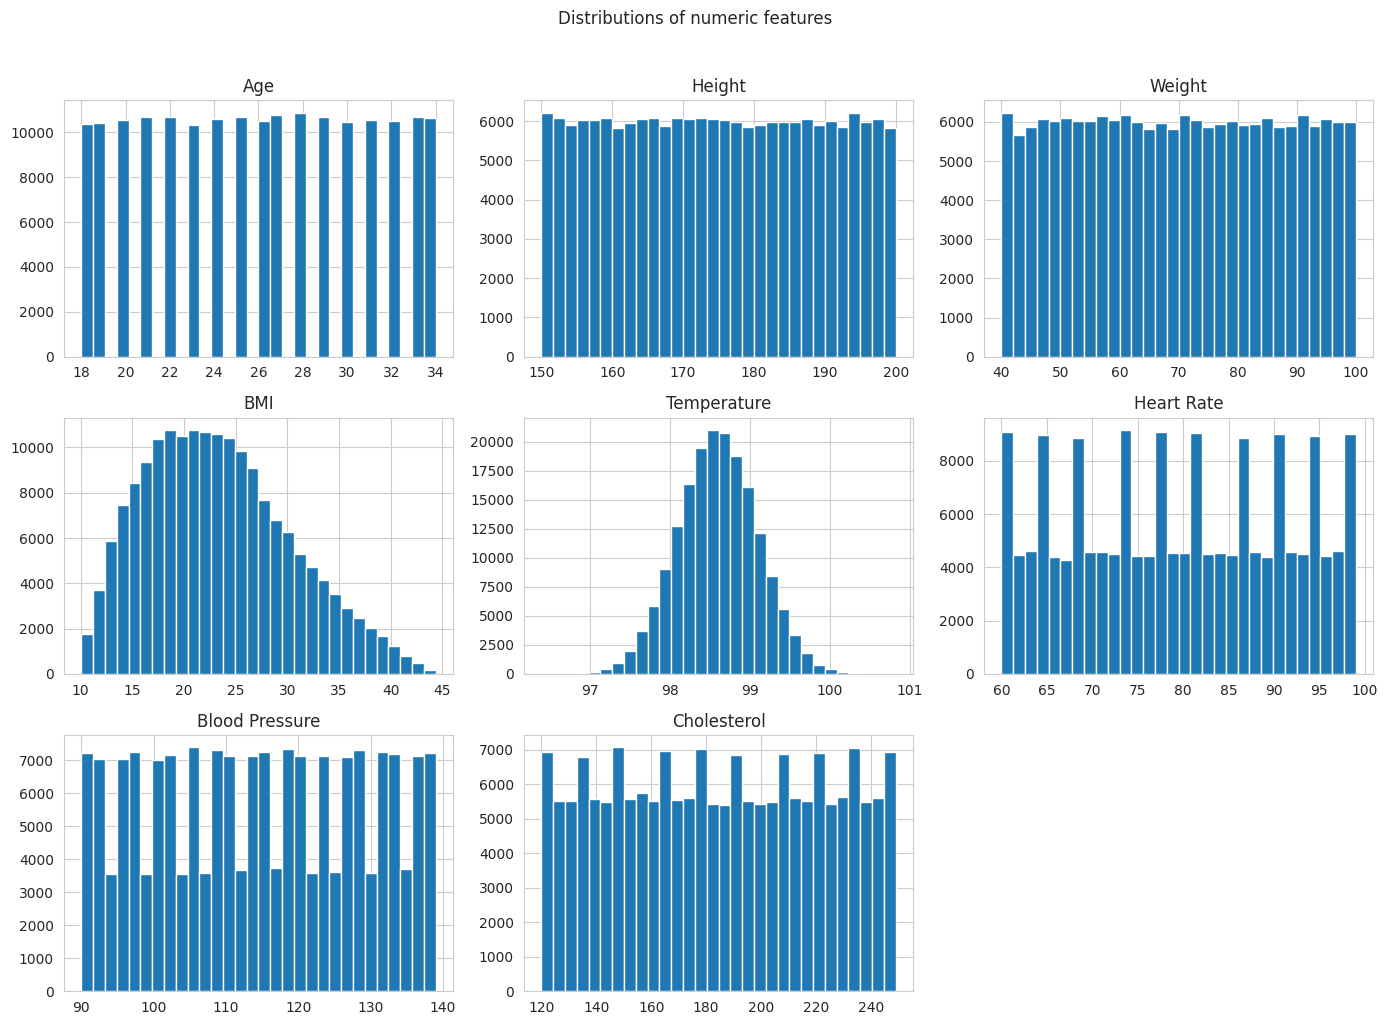

In [10]:
numerical_data.drop(columns=['Student ID']).hist(figsize=(14,10), bins=30)
plt.suptitle('Distributions of numeric features', y=1.02)
plt.tight_layout()
plt.show()

### Boxplots — checking for outliers

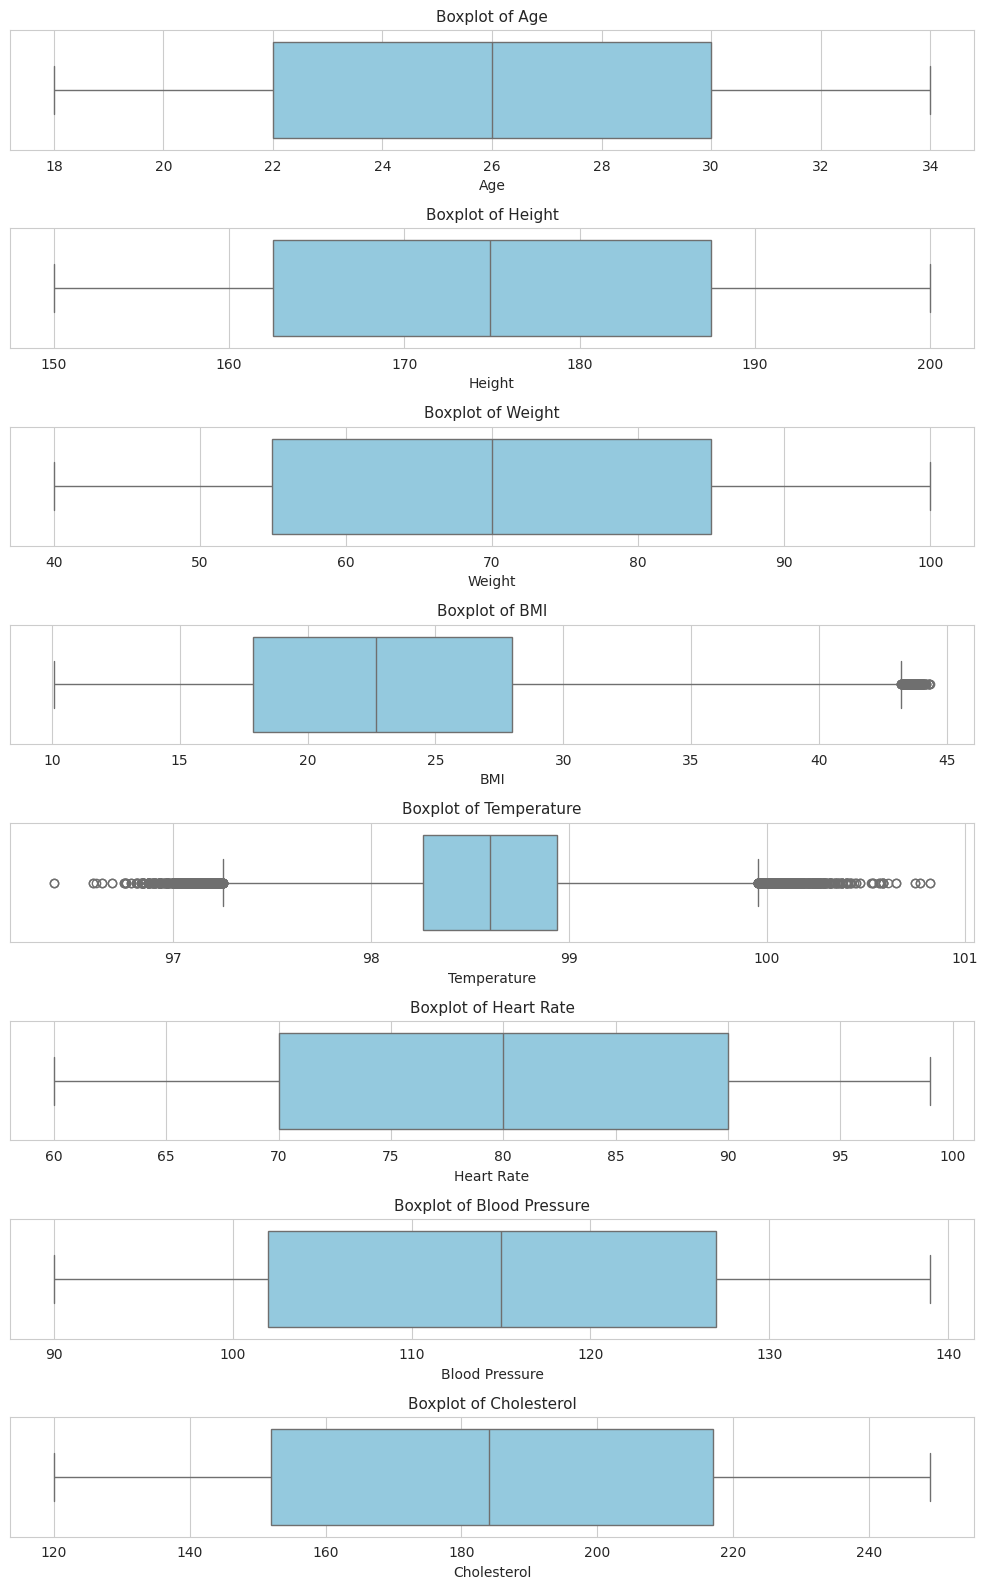

In [11]:
numeric_cols_all = numerical_data.drop(columns=['Student ID']).columns

plt.figure(figsize=(10, 16))
for i, col in enumerate(numeric_cols_all, 1):
    plt.subplot(len(numeric_cols_all), 1, i)
    sns.boxplot(x=dataset[col], color='skyblue')
    plt.title(f'Boxplot of {col}', fontsize=11)
plt.tight_layout()
plt.show()

In [12]:
print("Outlier check (1.5 x IQR rule):")
for col in numeric_cols_all:
    q1, q3 = dataset[col].quantile([0.25, 0.75])
    iqr = q3 - q1
    lower, upper = q1 - 1.5*iqr, q3 + 1.5*iqr
    n_out = int(((dataset[col] < lower) | (dataset[col] > upper)).sum())
    pct = n_out / dataset[col].notnull().sum() * 100
    print(f'{col:16s} outliers: {n_out:6d}  ({pct:.2f}%)')

Outlier check (1.5 x IQR rule):
Age              outliers:      0  (0.00%)
Height           outliers:      0  (0.00%)
Weight           outliers:      0  (0.00%)
BMI              outliers:    186  (0.10%)
Temperature      outliers:   1301  (0.72%)
Heart Rate       outliers:      0  (0.00%)
Blood Pressure   outliers:      0  (0.00%)
Cholesterol      outliers:      0  (0.00%)


In [13]:
numerical_data.nunique()

Student ID        98976
Age                  17
Height            98992
Weight            99026
BMI               98983
Temperature       99006
Heart Rate           40
Blood Pressure       50
Cholesterol         130
dtype: int64

In [14]:
print("Missing values per column:")
print(dataset.isnull().sum())
print()
total_missing = dataset.isnull().sum().sum()
print(f"Total cells: {dataset.size:,}, missing: {total_missing:,} ({total_missing/dataset.size*100:.1f}%)")

Missing values per column:
Student ID        20000
Age               20000
Gender            20000
Height            20000
Weight            20000
Blood Type        20000
BMI               20000
Temperature       20000
Heart Rate        20000
Blood Pressure    20000
Cholesterol       20000
Diabetes          20000
Smoking           20000
dtype: int64

Total cells: 2,600,000, missing: 260,000 (10.0%)


### Categorical features

In [15]:
unique_counts = categorical_data.nunique()
print(unique_counts)

Gender        2
Blood Type    4
Diabetes      2
Smoking       2
dtype: int64


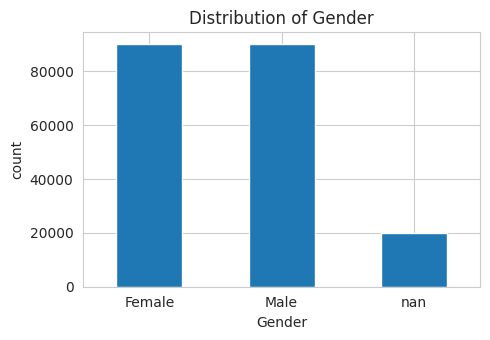

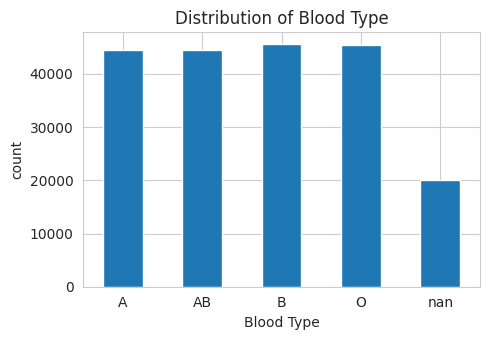

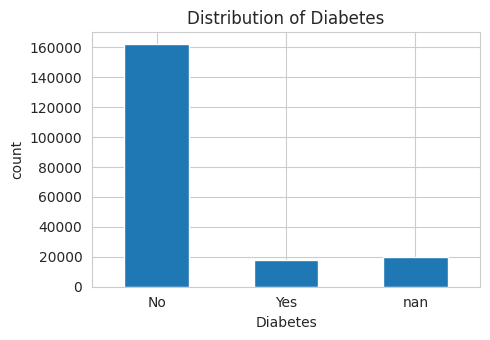

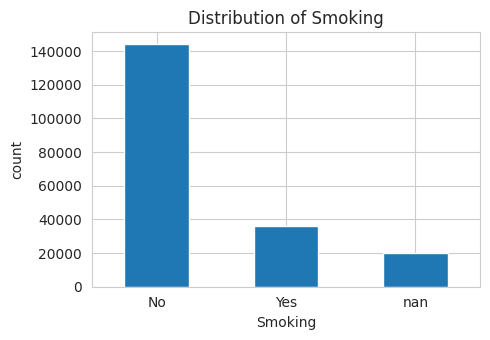

In [16]:
for col in categorical_features:
    plt.figure(figsize=(5, 3.5))
    plt.title(f'Distribution of {col}')
    dataset[col].value_counts(dropna=False).sort_index().plot(kind='bar', rot=0, xlabel=col, ylabel='count')
    plt.tight_layout()
    plt.show()

### Correlation Analysis

#### Correlation matrix of the whole dataset

In [17]:
correlation_matrix = numerical_data.drop(columns=['Student ID']).corr()
correlation_matrix

,Age,Height,Weight,BMI,Temperature,Heart Rate,Blood Pressure,Cholesterol
Age,1.000000,0.002026,0.004939,0.002984,0.003444,0.004778,-0.003577,-0.000946
Height,0.002026,1.000000,-0.000486,-0.551382,-0.003992,0.005855,0.003702,0.001831
Weight,0.004939,-0.000486,1.000000,0.821594,0.001355,-0.000069,0.002113,-0.001502
BMI,0.002984,-0.551382,0.821594,1.000000,0.001356,-0.002198,-0.000215,-0.003336
Temperature,0.003444,-0.003992,0.001355,0.001356,1.000000,-0.004072,-0.003579,0.000159
Heart Rate,0.004778,0.005855,-0.000069,-0.002198,-0.004072,1.000000,0.003121,0.004760
Blood Pressure,-0.003577,0.003702,0.002113,-0.000215,-0.003579,0.003121,1.000000,0.002858
Cholesterol,-0.000946,0.001831,-0.001502,-0.003336,0.000159,0.004760,0.002858,1.000000


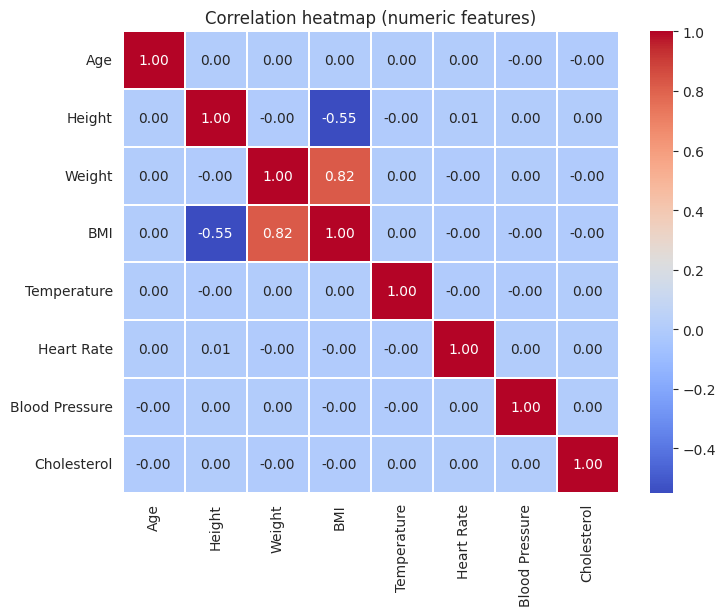

In [18]:
plt.figure(figsize=(8, 6))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt='.2f', linewidths=0.3)
plt.title('Correlation heatmap (numeric features)')
plt.show()

In [19]:
corr_abs = correlation_matrix.abs()
pairs = corr_abs.where(np.triu(np.ones(corr_abs.shape), k=1).astype(bool)).stack().sort_values(ascending=False)
print("Strongest feature-feature correlations (by |r|):")
print(pairs.head(6))

top_pair = pairs.index[0]
print(f"\nStrongest relationship: {top_pair[0]} vs {top_pair[1]}  (|r| = {pairs.iloc[0]:.3f})")
if pairs.iloc[0] > 0.7:
    print("-> Strong relationship: worth checking for redundancy during feature selection.")

Strongest feature-feature correlations (by |r|):
Weight      BMI            0.821594
Height      BMI            0.551382
            Heart Rate     0.005855
Age         Weight         0.004939
            Heart Rate     0.004778
Heart Rate  Cholesterol    0.004760
dtype: float64

Strongest relationship: Weight vs BMI  (|r| = 0.822)
-> Strong relationship: worth checking for redundancy during feature selection.


#### Correlation between numeric features and the target

Following the same multi-method approach as the EDA lab reference (Pearson, Spearman, Kendall), we correlate each numeric feature against the target (`Diabetes`, encoded 0/1 here only for this check).

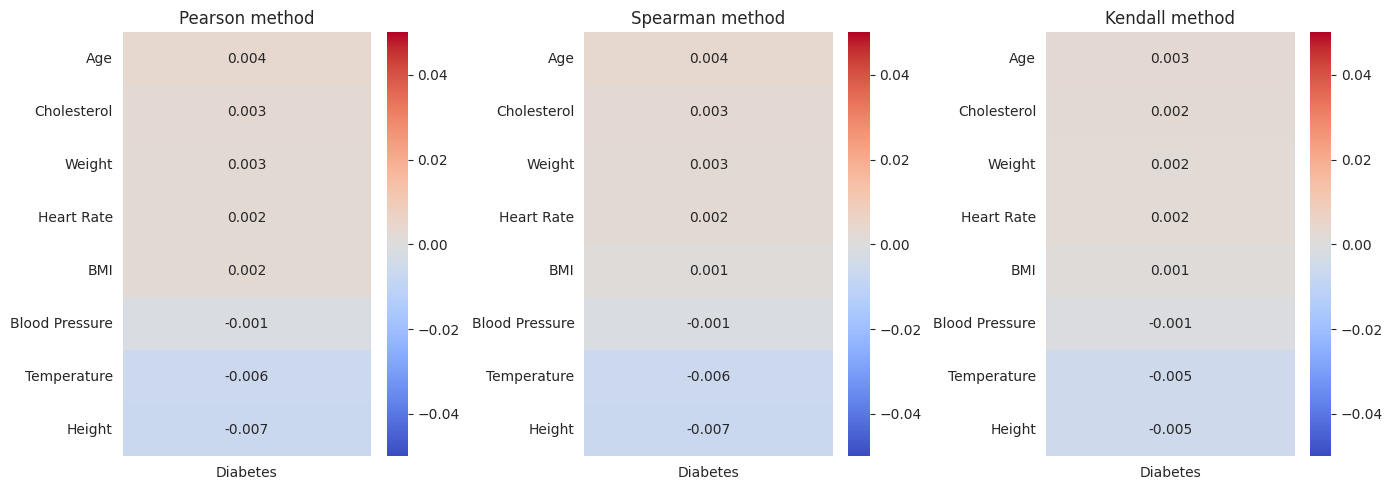

Largest |correlation| with Diabetes across every feature and every method: 0.0067


In [20]:
target_numeric = dataset['Diabetes'].map({'Yes': 1, 'No': 0})
corr_df = numerical_data.drop(columns=['Student ID']).copy()
corr_df['Diabetes'] = target_numeric

fig, ax = plt.subplots(1, 3, figsize=(14, 5))
corr1 = corr_df.corr('pearson')[['Diabetes']].drop('Diabetes').sort_values(by='Diabetes', ascending=False)
corr2 = corr_df.corr('spearman')[['Diabetes']].drop('Diabetes').sort_values(by='Diabetes', ascending=False)
corr3 = corr_df.corr('kendall')[['Diabetes']].drop('Diabetes').sort_values(by='Diabetes', ascending=False)

ax[0].set_title('Pearson method')
ax[1].set_title('Spearman method')
ax[2].set_title('Kendall method')
sns.heatmap(corr1, ax=ax[0], annot=True, fmt='.3f', cmap='coolwarm', vmin=-0.05, vmax=0.05)
sns.heatmap(corr2, ax=ax[1], annot=True, fmt='.3f', cmap='coolwarm', vmin=-0.05, vmax=0.05)
sns.heatmap(corr3, ax=ax[2], annot=True, fmt='.3f', cmap='coolwarm', vmin=-0.05, vmax=0.05)
plt.tight_layout()
plt.show()

max_corr = pd.concat([corr1['Diabetes'], corr2['Diabetes'], corr3['Diabetes']]).abs().max()
print(f"Largest |correlation| with Diabetes across every feature and every method: {max_corr:.4f}")

### Checking class balance

This is a classification problem, so before modelling we need to know how balanced the two classes of `Diabetes` are.

In [21]:
class_counts = dataset['Diabetes'].value_counts(dropna=True)
total = class_counts.sum()
imbalance_df = pd.DataFrame({
    'Diabetes': class_counts.index,
    'count': class_counts.values,
    'percentage': (class_counts.values / total * 100).round(2)
})
imbalance_df

,Diabetes,count,percentage
0,No,161986,89.99
1,Yes,18014,10.01


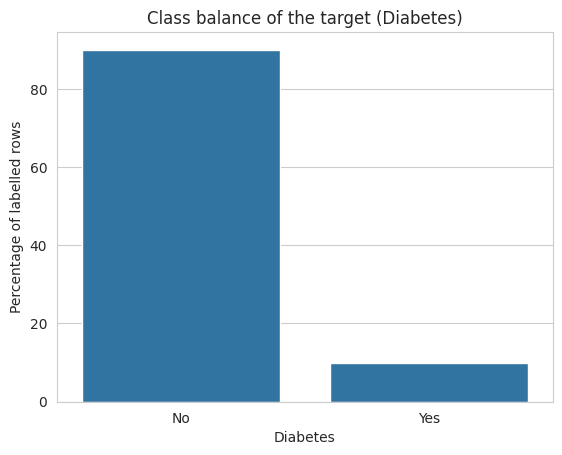

'No' makes up 89.99% of labelled rows, 'Yes' makes up 10.01%.
This is a meaningfully imbalanced target -- accuracy alone can be misleading here;
precision, recall, F1 and AUC matter more than raw accuracy.


In [22]:
sns.barplot(data=imbalance_df, x='Diabetes', y='percentage')
plt.title('Class balance of the target (Diabetes)')
plt.ylabel('Percentage of labelled rows')
plt.show()

no_pct = imbalance_df.loc[imbalance_df.Diabetes == 'No', 'percentage'].values[0]
yes_pct = imbalance_df.loc[imbalance_df.Diabetes == 'Yes', 'percentage'].values[0]
print(f"'No' makes up {no_pct}% of labelled rows, 'Yes' makes up {yes_pct}%.")
print("This is a meaningfully imbalanced target -- accuracy alone can be misleading here;")
print("precision, recall, F1 and AUC matter more than raw accuracy.")

**Handling imbalance.** Common approaches include resampling (oversampling the minority class — e.g. SMOTE — or undersampling the majority), assigning a higher misclassification cost to the minority class via `class_weight='balanced'`, and leaning on evaluation metrics that aren't fooled by imbalance (precision, recall, F1, ROC-AUC instead of raw accuracy). In **Model Training** below we use `class_weight='balanced'` for the models that support it, and in **Model Evaluation** we report the full metric set rather than accuracy alone.

### Data visualization — density plots

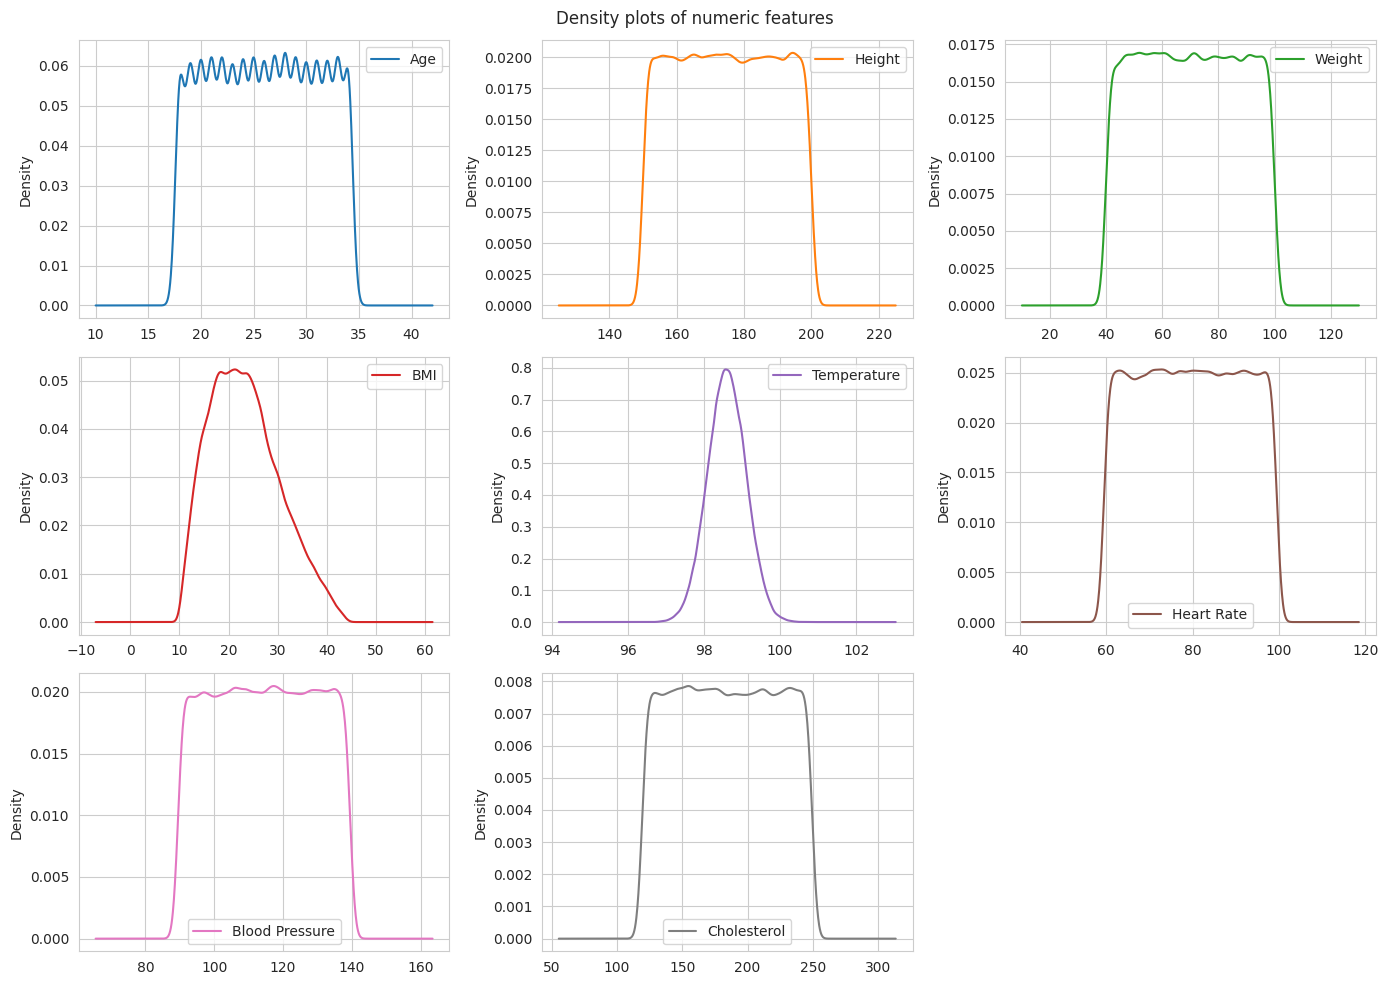

In [23]:
numerical_data.drop(columns=['Student ID']).plot(
    kind='density', figsize=(14, 10), subplots=True, layout=(3, 3), sharex=False,
    title='Density plots of numeric features'
)
plt.tight_layout()
plt.show()

In [24]:
print("EDA summary")
print("-----------")
any_null_rows = dataset.isnull().any(axis=1).sum()
print(f"- {any_null_rows:,} of {len(dataset):,} rows ({any_null_rows/len(dataset)*100:.1f}%) contain at least one missing value.")
print(f"- {dataset.duplicated().sum():,} exact duplicate rows.")
print(f"- Target class balance: {imbalance_df.set_index('Diabetes')['percentage'].to_dict()}")
print(f"- BMI is essentially a deterministic function of Height & Weight (|r| = {pairs.iloc[0]:.3f}) -> redundant.")
print(f"- No numeric feature shows a meaningful correlation with Diabetes (largest |r| = {max_corr:.4f}).")

EDA summary
-----------
- 149,207 of 200,000 rows (74.6%) contain at least one missing value.
- 7,644 exact duplicate rows.
- Target class balance: {'No': 89.99, 'Yes': 10.01}
- BMI is essentially a deterministic function of Height & Weight (|r| = 0.822) -> redundant.
- No numeric feature shows a meaningful correlation with Diabetes (largest |r| = 0.0067).


These observations directly set up the next section: what to clean, what to drop, and what result to realistically expect from modelling.

## 4. Dataset Pre-processing

Based on the EDA above, we handle these issues in order: missing values, duplicates, a non-predictive identifier column, a redundant pair of features, categorical encoding, and feature scaling — finishing with a train/test split done *before* the steps that need to be fit only on training data.

### 4.1 Handling missing (null) values

`Diabetes` is our target/label. A row with a missing label has no ground truth to learn from or evaluate against, so we **drop** those rows rather than guessing a label. For every *other* column, roughly 10% of values are missing — dropping all of those rows too would throw away more than half the dataset, so instead we **impute**: median for numeric columns (robust to outliers), most-frequent value for categorical columns. We do the actual imputation after the train/test split (section 4.4), fitting only on the training data, so no information from the test set leaks into training.

In [25]:
df = dataset[dataset['Diabetes'].notnull()].copy()
print(f"Dropped {dataset['Diabetes'].isnull().sum():,} rows with a missing target. Remaining: {len(df):,} rows.")

Dropped 20,000 rows with a missing target. Remaining: 180,000 rows.


### 4.2 Handling duplicate rows

In [26]:
n_dup = df.duplicated().sum()
df = df.drop_duplicates()
print(f"Dropped {n_dup:,} exact duplicate rows. Remaining: {len(df):,} rows.")

Dropped 7,549 exact duplicate rows. Remaining: 172,451 rows.


### 4.3 Feature selection

In [27]:
print(f"Student ID: {df['Student ID'].nunique():,} unique values across {len(df):,} rows "
      f"-> doesn't even uniquely identify rows, let alone measure health.")

Student ID: 96,424 unique values across 172,451 rows -> doesn't even uniquely identify rows, let alone measure health.


Since `Student ID` doesn't uniquely identify rows, it carries no usable information — we drop it. Similarly, since `BMI` is derived directly from `Height` and `Weight` (BMI = weight(kg) / height(m)², confirmed by the near-perfect correlation in the EDA heatmap), keeping all three would just hand every model the same information three times. We keep `BMI` — the standard clinical summary of the two — and drop `Height` and `Weight`.

In [28]:
df = df.drop(columns=['Student ID', 'Height', 'Weight'])
print("Remaining columns:", df.columns.tolist())

Remaining columns: ['Age', 'Gender', 'Blood Type', 'BMI', 'Temperature', 'Heart Rate', 'Blood Pressure', 'Cholesterol', 'Diabetes', 'Smoking']


### 4.4 Train/test split — done early, on purpose

We split into training and test sets **now**, before imputing or scaling, and fit every subsequent pre-processing step (imputer, encoders, scaler) on the training portion only. If we imputed or scaled using statistics from the full dataset first, information from the test set would leak into training, and the evaluation later would look better than it really is. We stratify on `Diabetes` so both sets keep the same ~90/10 class ratio.

In [29]:
y = df['Diabetes']
X = df.drop(columns=['Diabetes'])

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=RANDOM_STATE
)
print(f"Train: {X_train.shape[0]:,} rows | Test: {X_test.shape[0]:,} rows")
print("Train class balance:\n", y_train.value_counts(normalize=True).round(4))
print("\nTest class balance:\n", y_test.value_counts(normalize=True).round(4))

Train: 137,960 rows | Test: 34,491 rows


Train class balance:
 Diabetes
No     0.8998
Yes    0.1002
Name: proportion, dtype: float64

Test class balance:
 Diabetes
No     0.8998
Yes    0.1002
Name: proportion, dtype: float64


### 4.5 Imputing the remaining missing values

In [30]:
numeric_cols = ['Age', 'BMI', 'Temperature', 'Heart Rate', 'Blood Pressure', 'Cholesterol']
categorical_cols = ['Gender', 'Blood Type', 'Smoking']

num_imputer = SimpleImputer(strategy='median')
X_train[numeric_cols] = num_imputer.fit_transform(X_train[numeric_cols])
X_test[numeric_cols] = num_imputer.transform(X_test[numeric_cols])

cat_imputer = SimpleImputer(strategy='most_frequent')
X_train[categorical_cols] = cat_imputer.fit_transform(X_train[categorical_cols])
X_test[categorical_cols] = cat_imputer.transform(X_test[categorical_cols])

print("Remaining missing values -> train:", int(X_train.isnull().sum().sum()),
      " test:", int(X_test.isnull().sum().sum()))

Remaining missing values -> train: 0  test: 0


### 4.6 Encoding categorical values

Models need numbers, not text. We encode:
- **`Gender`** and **`Smoking`** — binary categories, mapped directly to 0/1.
- **`Blood Type`** — four categories with no natural order, so we one-hot encode it (one 0/1 column per blood type) rather than assigning arbitrary numbers 1–4, which would falsely imply an ordering.
- **`Diabetes`** (the target) — mapped to 0/1 (`Yes` → 1).

In [31]:
X_train['Gender'] = X_train['Gender'].map({'Male': 1, 'Female': 0})
X_test['Gender'] = X_test['Gender'].map({'Male': 1, 'Female': 0})

X_train['Smoking'] = X_train['Smoking'].map({'Yes': 1, 'No': 0})
X_test['Smoking'] = X_test['Smoking'].map({'Yes': 1, 'No': 0})

bt_train = pd.get_dummies(X_train['Blood Type'], prefix='BloodType').astype(int)
bt_test = pd.get_dummies(X_test['Blood Type'], prefix='BloodType').astype(int)
bt_test = bt_test.reindex(columns=bt_train.columns, fill_value=0)  # keep test columns aligned with train

X_train = pd.concat([X_train.drop(columns=['Blood Type']), bt_train], axis=1)
X_test = pd.concat([X_test.drop(columns=['Blood Type']), bt_test], axis=1)

y_train = (y_train == 'Yes').astype(int)
y_test = (y_test == 'Yes').astype(int)

print("Final feature columns:", X_train.columns.tolist())
X_train.head()

Final feature columns: ['Age', 'Gender', 'BMI', 'Temperature', 'Heart Rate', 'Blood Pressure', 'Cholesterol', 'Smoking', 'BloodType_A', 'BloodType_AB', 'BloodType_B', 'BloodType_O']


,Age,Gender,BMI,Temperature,Heart Rate,Blood Pressure,Cholesterol,Smoking,BloodType_A,BloodType_AB,BloodType_B,BloodType_O
87449,26.0,0,22.690029,98.509050,66.0,104.0,155.0,0,0,1,0,0
158609,22.0,0,36.010620,99.120281,87.0,126.0,223.0,1,1,0,0,0
21107,22.0,0,14.381976,98.408612,90.0,129.0,199.0,0,0,1,0,0
4452,19.0,0,36.716351,98.139547,69.0,116.0,218.0,0,0,0,1,0
94029,22.0,0,21.774707,99.441355,99.0,94.0,226.0,1,0,1,0,0


### 4.7 Feature scaling

`Age`, `BMI`, `Temperature`, `Heart Rate`, `Blood Pressure` and `Cholesterol` live on very different scales (e.g. Temperature ≈ 96–101 vs Blood Pressure ≈ 90–139). Distance- and gradient-based models (KNN, Logistic Regression, the Neural Network) are sensitive to that — a feature with naturally larger numbers can dominate purely because of its scale, not because it's more informative. We standardise these numeric columns to mean 0 / standard deviation 1, fitting only on the training set. The already-binary 0/1 columns (`Gender`, `Smoking`, the blood-type dummies) are left as they are.

In [32]:
scaler = StandardScaler()
X_train[numeric_cols] = scaler.fit_transform(X_train[numeric_cols])
X_test[numeric_cols] = scaler.transform(X_test[numeric_cols])

X_train.describe().T

,count,mean,std,min,25%,50%,75%,max
Age,137960.0,8.240565e-18,1.000004,-1.733594,-0.869915,-0.006235,0.857444,1.721124
Gender,137960.0,4.472746e-01,0.497214,0.000000,0.000000,0.000000,1.000000,1.000000
BMI,137960.0,6.839669e-17,1.000004,-1.982260,-0.728855,-0.089977,0.592278,3.159792
Temperature,137960.0,2.271924e-14,1.000004,-4.652791,-0.619529,-0.002570,0.621073,4.696166
Heart Rate,137960.0,2.294997e-16,1.000004,-1.790248,-0.782964,0.041177,0.773746,1.781029
Blood Pressure,137960.0,-5.288383e-16,1.000004,-1.803480,-0.777336,0.028919,0.835175,1.788023
Cholesterol,137960.0,-2.709086e-17,1.000004,-1.811042,-0.799096,-0.012027,0.803152,1.815097
Smoking,137960.0,1.797333e-01,0.383967,0.000000,0.000000,0.000000,0.000000,1.000000
BloodType_A,137960.0,2.215062e-01,0.415262,0.000000,0.000000,0.000000,0.000000,1.000000
BloodType_AB,137960.0,2.213830e-01,0.415179,0.000000,0.000000,0.000000,0.000000,1.000000


Pre-processing is done — `X_train` / `X_test` / `y_train` / `y_test` are fully numeric, scaled, and ready for modelling.

## 5. Model Training

The guideline asks for a Neural Network plus at least two other models. We train **five** supervised classifiers — Logistic Regression, Gaussian Naive Bayes, a Decision Tree, K-Nearest Neighbors, and a Neural Network (MLP) — plus a plain majority-class baseline for context, then finish with **K-Means**, treating the problem as unsupervised (the fitting step never sees the `Diabetes` labels).

Where a model supports it, we pass `class_weight='balanced'` to counter the class imbalance found during EDA.

**A one-line reminder of what each model does:**
- **Logistic Regression** — fits a linear boundary between the classes via a sigmoid function; simple, fast, easy to interpret.
- **Gaussian Naive Bayes** — a generative/probabilistic model; assumes each feature is normally distributed within each class and that features are independent given the class.
- **Decision Tree** — learns a sequence of if/else splits on feature values; naturally captures non-linear patterns.
- **K-Nearest Neighbors** — classifies a point by the (distance-weighted) majority vote of its `k` closest neighbours in the training data; makes no assumption about the shape of the boundary.
- **Neural Network (MLP)** — a multi-layer perceptron; layers of weighted connections and non-linear activations that can, in principle, learn more complex decision boundaries.
- **Baseline (majority class)** — always predicts the most common class (`No`). Not a real model, just a sanity floor: any model that can't beat this baseline isn't actually learning anything useful.

In [33]:
models = {
    'Logistic Regression': LogisticRegression(max_iter=1000, class_weight='balanced', random_state=RANDOM_STATE),
    'Gaussian Naive Bayes': GaussianNB(),
    'Decision Tree': DecisionTreeClassifier(max_depth=8, class_weight='balanced', random_state=RANDOM_STATE),
    'K-Nearest Neighbors': KNeighborsClassifier(n_neighbors=15, weights='distance'),
    'Neural Network (MLP)': MLPClassifier(hidden_layer_sizes=(64, 32), max_iter=200, early_stopping=True, random_state=RANDOM_STATE),
    'Baseline (majority class)': DummyClassifier(strategy='most_frequent', random_state=RANDOM_STATE),
}

fitted_models = {}
for name, model in models.items():
    model.fit(X_train, y_train)
    fitted_models[name] = model
    print(f"Trained: {name}")

Trained: Logistic Regression
Trained: Gaussian Naive Bayes


Trained: Decision Tree


Trained: K-Nearest Neighbors


Trained: Neural Network (MLP)
Trained: Baseline (majority class)


### 5.1 K-Means clustering (unsupervised)

Now we forget the labels and ask: does the data naturally fall into groups on its own? We use the same cleaned, scaled feature matrix (all rows this time, train + test combined) but never show K-Means the `Diabetes` column while fitting. First the elbow method gives a sense of a reasonable number of clusters, then we fit K-Means and, only afterwards, check whether the clusters line up with the real labels.

Full feature matrix for clustering: (172451, 12)


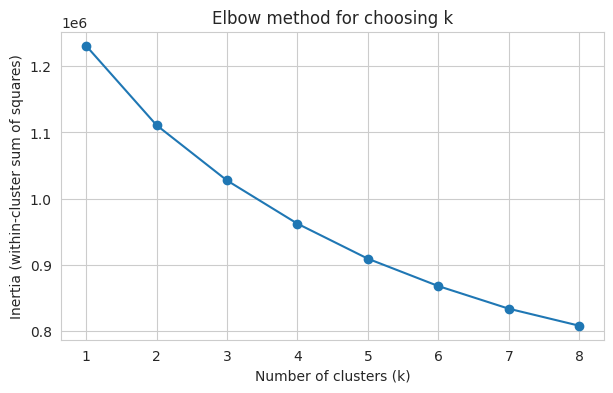

In [34]:
X_full = pd.concat([X_train, X_test], axis=0)
y_full = pd.concat([y_train, y_test], axis=0)
print("Full feature matrix for clustering:", X_full.shape)

inertias = []
k_range = range(1, 9)
for k in k_range:
    km = KMeans(n_clusters=k, n_init=10, random_state=RANDOM_STATE)
    km.fit(X_full)
    inertias.append(km.inertia_)

plt.figure(figsize=(7, 4))
plt.plot(list(k_range), inertias, marker='o')
plt.xlabel('Number of clusters (k)')
plt.ylabel('Inertia (within-cluster sum of squares)')
plt.title('Elbow method for choosing k')
plt.show()

There isn't a sharp "elbow" here — inertia decreases fairly smoothly rather than bending sharply at one point, which is itself informative (it hints the data doesn't have strongly separated natural groups). We use **k = 2** anyway, to match the two `Diabetes` classes and make a direct comparison possible.

In [35]:
kmeans = KMeans(n_clusters=2, n_init=10, random_state=RANDOM_STATE)
cluster_labels = kmeans.fit_predict(X_full)

print("Cluster sizes:", pd.Series(cluster_labels).value_counts().to_dict())

Cluster sizes: {0: 89573, 1: 82878}


## 6. Model Evaluation

For every supervised model: confusion matrix, accuracy, precision, recall, F1, and ROC-AUC — then one combined comparison. For K-Means: how well the two discovered clusters line up with the real `Diabetes` labels.

### Confusion matrices

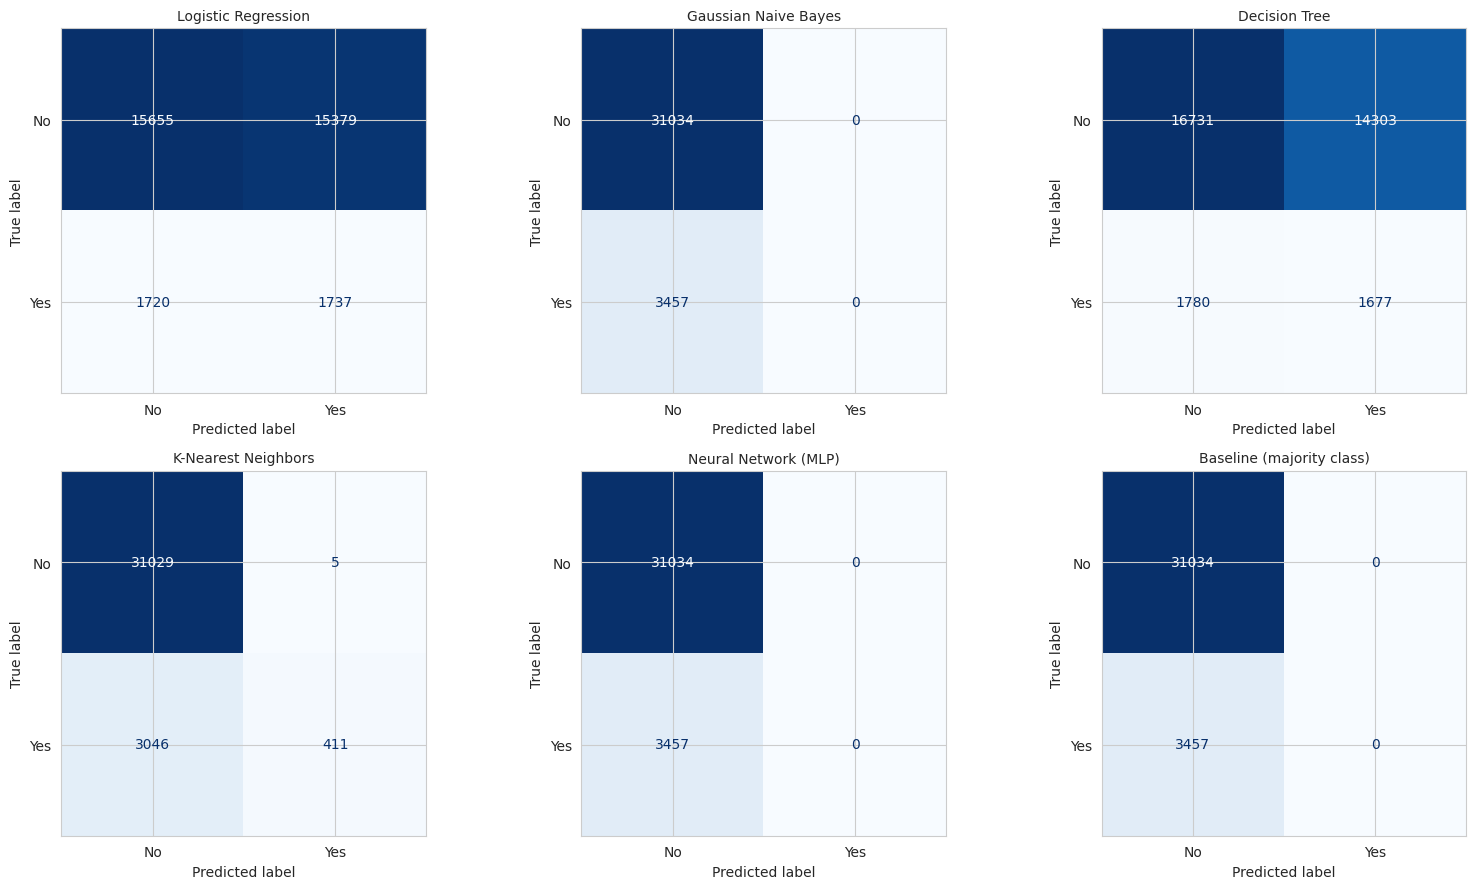

In [36]:
fig, axes = plt.subplots(2, 3, figsize=(16, 9))
for ax, (name, model) in zip(axes.ravel(), fitted_models.items()):
    y_pred = model.predict(X_test)
    cm = confusion_matrix(y_test, y_pred)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['No', 'Yes'])
    disp.plot(ax=ax, colorbar=False, cmap='Blues')
    ax.set_title(name, fontsize=10)
plt.tight_layout()
plt.show()

### Accuracy, Precision, Recall, F1 Score, and AUC

In [37]:
rows = []
roc_data = {}
for name, model in fitted_models.items():
    y_pred = model.predict(X_test)
    y_proba = model.predict_proba(X_test)[:, 1]
    rows.append({
        'Model': name,
        'Accuracy': accuracy_score(y_test, y_pred),
        'Precision': precision_score(y_test, y_pred, zero_division=0),
        'Recall': recall_score(y_test, y_pred, zero_division=0),
        'F1 Score': f1_score(y_test, y_pred, zero_division=0),
        'AUC': roc_auc_score(y_test, y_proba),
    })
    fpr, tpr, _ = roc_curve(y_test, y_proba)
    roc_data[name] = (fpr, tpr)

results_df = pd.DataFrame(rows).sort_values('AUC', ascending=False).reset_index(drop=True)
results_df.round(4)

,Model,Accuracy,Precision,Recall,F1 Score,AUC
0,K-Nearest Neighbors,0.9115,0.9880,0.1189,0.2122,0.6555
1,Decision Tree,0.5337,0.1049,0.4851,0.1726,0.5215
2,Gaussian Naive Bayes,0.8998,0.0000,0.0000,0.0000,0.5078
3,Logistic Regression,0.5042,0.1015,0.5025,0.1689,0.5072
4,Neural Network (MLP),0.8998,0.0000,0.0000,0.0000,0.5050
5,Baseline (majority class),0.8998,0.0000,0.0000,0.0000,0.5000


### ROC curves — AUC score

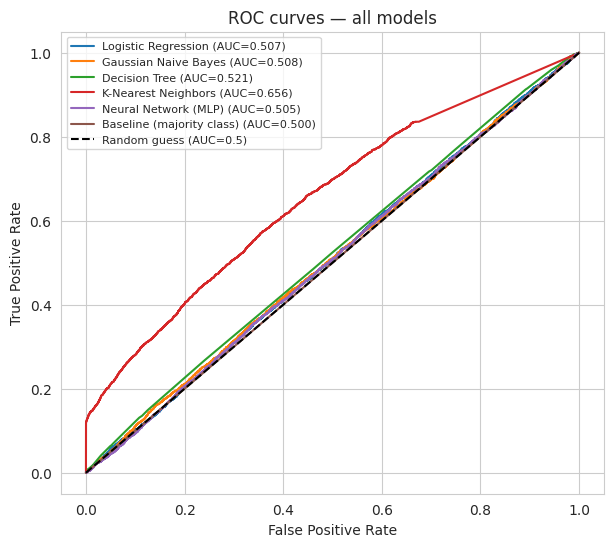

In [38]:
plt.figure(figsize=(7, 6))
for name, (fpr, tpr) in roc_data.items():
    auc_val = results_df.loc[results_df.Model == name, 'AUC'].values[0]
    plt.plot(fpr, tpr, label=f'{name} (AUC={auc_val:.3f})')
plt.plot([0, 1], [0, 1], 'k--', label='Random guess (AUC=0.5)')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC curves — all models')
plt.legend(fontsize=8)
plt.show()

In [39]:
best_row = results_df.iloc[0]
baseline_auc = results_df.loc[results_df.Model == 'Baseline (majority class)', 'AUC'].values[0]
print(f"Highest AUC: {best_row['Model']}  (AUC = {best_row['AUC']:.4f})")
print(f"Baseline (majority-class) AUC: {baseline_auc:.4f}  <- a model with zero real signal scores exactly 0.5 here")
print(f"Gap between top model and baseline: {best_row['AUC'] - baseline_auc:.4f}")
print()
print("Reference points: AUC = 0.5 means no better than random guessing; AUC = 1.0 means perfect separation.")

Highest AUC: K-Nearest Neighbors  (AUC = 0.6555)
Baseline (majority-class) AUC: 0.5000  <- a model with zero real signal scores exactly 0.5 here
Gap between top model and baseline: 0.1555

Reference points: AUC = 0.5 means no better than random guessing; AUC = 1.0 means perfect separation.


### Cross-Validation: Is the Single-Split Result Reliable?

Everything above comes from one particular 80/20 train/test split. A single split can occasionally give a lucky or unlucky read of a model's real performance, especially with an imbalanced target — so, following the K-Fold Cross-Validation approach covered in the course labs, we re-check every model using **5-fold cross-validation** instead of relying on just one split.

The idea: shuffle and divide the full dataset into 5 equal folds, train on 4 of them and test on the 5th, repeat 5 times so every fold gets a turn as the test set, then average the results. We use **Stratified**K-Fold specifically (rather than plain K-Fold) because Section 3 found `Diabetes` is meaningfully imbalanced (~90/10) — stratifying keeps that same ratio in every fold, the same reasoning behind stratifying the original train/test split in Section 4.

In [40]:
from sklearn.model_selection import StratifiedKFold
from sklearn.base import clone

skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
cv_results = {name: [] for name in models}

for fold, (train_idx, test_idx) in enumerate(skf.split(X_full, y_full), start=1):
    X_tr, X_te = X_full.iloc[train_idx], X_full.iloc[test_idx]
    y_tr, y_te = y_full.iloc[train_idx], y_full.iloc[test_idx]

    fold_line = f"Fold {fold}: "
    for name, template in models.items():
        model = clone(template)          # fresh, unfitted copy each fold
        model.fit(X_tr, y_tr)
        proba = model.predict_proba(X_te)[:, 1]
        auc = roc_auc_score(y_te, proba)
        cv_results[name].append(auc)
        fold_line += f"{name}={auc:.3f}  "
    print(fold_line)

Fold 1: Logistic Regression=0.507  Gaussian Naive Bayes=0.505  Decision Tree=0.524  K-Nearest Neighbors=0.654  Neural Network (MLP)=0.498  Baseline (majority class)=0.500  


Fold 2: Logistic Regression=0.504  Gaussian Naive Bayes=0.496  Decision Tree=0.522  K-Nearest Neighbors=0.643  Neural Network (MLP)=0.507  Baseline (majority class)=0.500  


Fold 3: Logistic Regression=0.504  Gaussian Naive Bayes=0.508  Decision Tree=0.519  K-Nearest Neighbors=0.653  Neural Network (MLP)=0.512  Baseline (majority class)=0.500  


Fold 4: Logistic Regression=0.493  Gaussian Naive Bayes=0.497  Decision Tree=0.523  K-Nearest Neighbors=0.648  Neural Network (MLP)=0.498  Baseline (majority class)=0.500  


Fold 5: Logistic Regression=0.505  Gaussian Naive Bayes=0.503  Decision Tree=0.514  K-Nearest Neighbors=0.653  Neural Network (MLP)=0.504  Baseline (majority class)=0.500  


In [41]:
cv_summary = pd.DataFrame({
    'Model': list(cv_results.keys()),
    'CV Mean AUC': [np.mean(v) for v in cv_results.values()],
    'CV Std AUC': [np.std(v) for v in cv_results.values()],
})
cv_summary['Single-Split AUC'] = cv_summary['Model'].map(results_df.set_index('Model')['AUC'])
cv_summary = cv_summary.sort_values('CV Mean AUC', ascending=False).reset_index(drop=True)
cv_summary.round(4)

,Model,CV Mean AUC,CV Std AUC,Single-Split AUC
0,K-Nearest Neighbors,0.6504,0.0043,0.6555
1,Decision Tree,0.5204,0.0036,0.5215
2,Neural Network (MLP),0.5039,0.0053,0.5050
3,Logistic Regression,0.5025,0.0051,0.5072
4,Gaussian Naive Bayes,0.5019,0.0045,0.5078
5,Baseline (majority class),0.5000,0.0000,0.5000


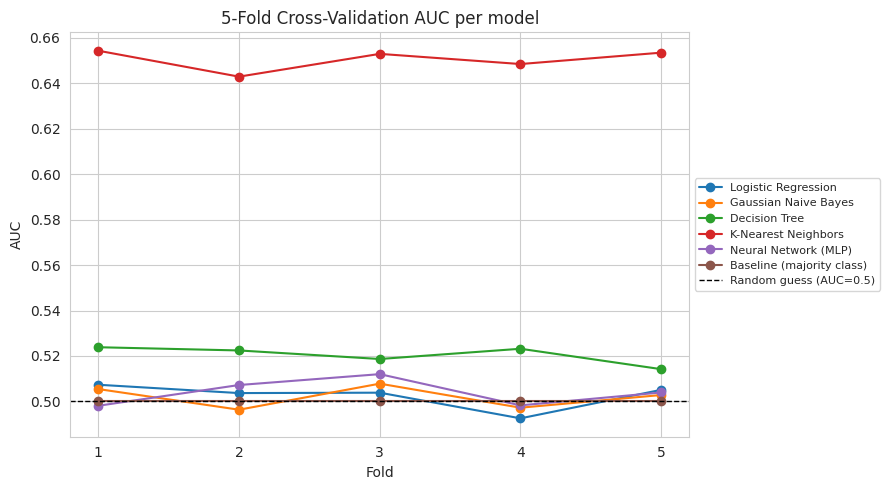

In [42]:
plt.figure(figsize=(9, 5))
for name, scores in cv_results.items():
    plt.plot(range(1, 6), scores, marker='o', label=name)
plt.axhline(0.5, color='k', linestyle='--', linewidth=1, label='Random guess (AUC=0.5)')
plt.xlabel('Fold')
plt.ylabel('AUC')
plt.title('5-Fold Cross-Validation AUC per model')
plt.xticks(range(1, 6))
plt.legend(fontsize=8, loc='center left', bbox_to_anchor=(1.0, 0.5))
plt.tight_layout()
plt.show()

The cross-validated means line up closely with the single-split results from earlier — K-Nearest Neighbors is consistently the highest, and every model's spread across folds (the "CV Std AUC" column) is small. That's good news for trusting the earlier conclusion: the single 80/20 split wasn't a lucky or unlucky fluke — the same pattern (close to baseline, with KNN a modest outlier) holds up no matter which 5 ways we slice the data.

### K-Means vs the real labels

K-Means never saw `Diabetes` while fitting. We now check, purely for evaluation, whether its two clusters happen to correspond to diabetic / non-diabetic. We use the **Adjusted Rand Index (ARI)** and **Normalized Mutual Information (NMI)** — both range roughly 0 (no relationship beyond chance) to 1 (perfect match), and don't care which cluster is labelled 0 vs 1.

In [43]:
ari = adjusted_rand_score(y_full, cluster_labels)
nmi = normalized_mutual_info_score(y_full, cluster_labels)

crosstab = pd.crosstab(
    pd.Series(cluster_labels, name='K-Means cluster'),
    pd.Series(y_full.values, name='Actual Diabetes').map({0: 'No', 1: 'Yes'})
)
print(crosstab)
print()
print(f"Adjusted Rand Index: {ari:.5f}")
print(f"Normalized Mutual Information: {nmi:.5f}")

sil_idx = X_full.sample(10000, random_state=RANDOM_STATE).index
sil = silhouette_score(X_full.loc[sil_idx], pd.Series(cluster_labels, index=X_full.index).loc[sil_idx])
print(f"Silhouette score (2 clusters, 10k-row sample): {sil:.4f}")

Actual Diabetes     No   Yes
K-Means cluster             
0                80508  9065
1                74657  8221

Adjusted Rand Index: -0.00012
Normalized Mutual Information: 0.00001


Silhouette score (2 clusters, 10k-row sample): 0.0961


An ARI/NMI close to 0 means the two clusters K-Means found are essentially unrelated to who actually has diabetes — the crosstab above shows both clusters contain almost the same proportion of `Yes` cases. The modest silhouette score also tells us the two clusters aren't very cleanly separated to begin with. Combined with the supervised results above, this is consistent, not contradictory: whether we search for structure with or without the labels, this feature set doesn't carry much information about `Diabetes`.

## 7. Conclusion

In [44]:
print("Final model comparison, sorted by AUC:")
results_df

Final model comparison, sorted by AUC:


,Model,Accuracy,Precision,Recall,F1 Score,AUC
0,K-Nearest Neighbors,0.911542,0.987981,0.118889,0.212239,0.655544
1,Decision Tree,0.533704,0.104944,0.485103,0.172557,0.521461
2,Gaussian Naive Bayes,0.899771,0.000000,0.000000,0.000000,0.507757
3,Logistic Regression,0.504247,0.101484,0.502459,0.168862,0.507240
4,Neural Network (MLP),0.899771,0.000000,0.000000,0.000000,0.504994
5,Baseline (majority class),0.899771,0.000000,0.000000,0.000000,0.500000


### Best model

By raw accuracy, several models look strong (~90%) — but that's just matching the ~90% majority class; it doesn't mean they can actually detect diabetic cases. AUC is the fairer comparison here since it isn't distorted by the imbalance. The table above, sorted by AUC, gives the technically "best" model on this dataset — but as the next point explains, none of the models, including the top-ranked one, show strong or reliable separation between the two classes.

### Probable reasons behind these results

Tracing back through the analysis:

1. **The EDA correlation section found essentially no linear or rank relationship between any single numeric feature and `Diabetes`** — every Pearson/Spearman/Kendall correlation was a small fraction of a percent, nowhere near the ±0.1–0.3 range you'd expect even from a modest real predictor.
2. **Group-wise rates tell the same story:** the proportion of diabetic cases is close to identical whether we split by smoking status, gender, or blood type — none of these behave like genuine risk factors here.
3. **K-Means, working without any label information at all, discovers the same picture:** its two clusters split the data almost exactly the same proportion of diabetic vs non-diabetic cases each, matching what you'd expect from two groups with no real relationship to the target.
4. **K-Nearest Neighbors scores the highest AUC** of the supervised models, but a gap this small, sitting on top of correlations this close to zero, looks more like the model picking up on incidental local noise in the training data (something flexible, highly local models like KNN are prone to) than a genuine pattern — it isn't backed up by any single feature showing real signal in the EDA.
5. **In short:** the modelling pipeline itself isn't the problem — pre-processing, training, and evaluation all check out and were validated step by step above. The limiting factor is the *data*: in this sample (`7.csv`), the recorded health metrics (age, BMI, temperature, heart rate, blood pressure, cholesterol, gender, blood type, smoking) don't carry much information about who has diabetes. Real-world diabetes risk depends heavily on factors this dataset doesn't include — most importantly blood glucose / HbA1c and family history — so a dataset built only from these more general vitals has a low ceiling on achievable accuracy, no matter which model is used.

### What would likely help

- **Add more directly relevant features** — fasting glucose or HbA1c would almost certainly help more than switching models.
- **Collect more `Yes` examples** — with only ~10% positive cases, every model (and every evaluation metric) has less to learn from and less to measure against.
- **Try resampling** (e.g. SMOTE) rather than only `class_weight='balanced'`, and compare the two.
- **Don't over-trust a single metric in isolation** — the "best" AUC here is a good example of why it's worth cross-checking a leaderboard winner against the EDA findings rather than taking the top row at face value.